<div style="background: linear-gradient(135deg, #0a0a1a 0%, #0d1b2e 50%, #0a0a1a 100%); padding: 40px 32px 32px 32px; border-radius: 12px; border: 1px solid #1e3a5f; margin-bottom: 8px;">

<div style="display: flex; align-items: flex-start; gap: 24px;">
<div style="flex: 1;">

<p style="color: #7eb8e0; font-family: 'Courier New', monospace; font-size: 20px; letter-spacing: 3px; margin: 0 0 10px 0; text-transform: uppercase;">Cosmic Explosion Exploration - LIGO Gravitational Wave Analysis Pipeline</p>

<h1 style="color: #e8f4fd; font-size: 2.2em; margin: 0 0 6px 0; font-weight: 300; letter-spacing: 1px;">Notebook 05 — Modelling</h1>

<p style="color: #a0c4de; font-size: 1.05em; margin: 0 0 20px 0; font-style: italic;">Matched filtering and post-Newtonian waveform modelling of GW150914</p>

<div style="display: flex; gap: 24px; flex-wrap: wrap;">
  <div style="background: rgba(126,184,224,0.08); border: 1px solid rgba(126,184,224,0.25); border-radius: 8px; padding: 12px 18px;">
    <p style="color: #7eb8e0; font-size: 11px; letter-spacing: 2px; margin: 0 0 4px 0; text-transform: uppercase;">Inputs</p>
    <p style="color: #e8f4fd; font-size: 0.95em; font-weight: 600; margin: 0; font-family: 'Courier New', monospace;">*_raw.hdf5 · *_processed.hdf5 · *_features.csv</p>
    <p style="color: #88a8c0; font-size: 12px; margin: 4px 0 0 0;">from notebooks 01, 02 &amp; 04</p>
  </div>
  <div style="background: rgba(126,184,224,0.08); border: 1px solid rgba(126,184,224,0.25); border-radius: 8px; padding: 12px 18px;">
    <p style="color: #7eb8e0; font-size: 11px; letter-spacing: 2px; margin: 0 0 4px 0; text-transform: uppercase;">Output</p>
    <p style="color: #e8f4fd; font-size: 0.95em; font-weight: 600; margin: 0; font-family: 'Courier New', monospace;">*_matched_filter_results.json</p>
    <p style="color: #88a8c0; font-size: 12px; margin: 4px 0 0 0;">ready for notebook 06</p>
  </div>
  <div style="background: rgba(126,184,224,0.08); border: 1px solid rgba(126,184,224,0.25); border-radius: 8px; padding: 12px 18px;">
    <p style="color: #7eb8e0; font-size: 11px; letter-spacing: 2px; margin: 0 0 4px 0; text-transform: uppercase;">Pipeline stage</p>
    <p style="color: #e8f4fd; font-size: 1.2em; font-weight: 600; margin: 0;">05 of 06</p>
    <p style="color: #88a8c0; font-size: 12px; margin: 4px 0 0 0;">matched filter · PN waveform · SNR</p>
  </div>
</div>

</div>
</div>

<hr style="border: none; border-top: 1px solid rgba(126,184,224,0.2); margin: 24px 0 16px 0;">

<p style="color: #7eb8e0; font-size: 12px; font-family: 'Courier New', monospace; margin: 0;">
  <span style="opacity:0.6;">Pipeline:</span> &nbsp;
</p>

</div>

In [1]:
from pipeline_banner import pipeline_banner
pipeline_banner(5)   # ← stage 05 active

## What is modelling from the perspective of this pipeline?

Notebooks 01–04 progressively cleaned and characterised the data which are typical steps in a data science pipeline flow.  
This notebook, however does something different — it builds a **physical model** based on scientific theory of what the resulting gravitational wave signal should look like based on the specific collision event of the two black holes with known masses. It then uses that model to interrogate the data directly and check if the observation matches the predicted outcome from the theory (in this case General Relavtivity and known physical laws).

So the modelling in this project is used to connect the data to the physics, verify that the previous pipeline steps are working as expected  and finally gives measure of the probability that the signal is a real gravitational wave.   

Two complementary modelling approaches are used:

1. **Matched filtering** — is the optimal linear algorithm for a known signal in Gaussian noise. It cross-correlates the data with a waveform template, weighted by the inverse noise power spectrum. Every frequency bin in the data is divided by the noise power at that frequency before being correlated with the template. The output is an SNR time-series that peaks sharply at the merger. The matched filter is optimal in the sense that no other linear algorithm extracts more SNR from the data, given the noise model. This is the same fundamental technique LIGO uses in its production detection pipelines.

2. **Post-Newtonian waveform template** — a semi-analytical model of the inspiral phase generated from the known component masses. It captures the physics of two objects slowly spiralling together under gravity, losing energy to gravitational wave emission. Comparing this theoretical prediction to the data builds intuition for how well General Relativity describes what was observed. In the production pipeline the comparison template bank can use thousands or millions of templates covering all plausible mass/spin combinations

| Section | Technique | Key output |
|---------|-----------|------------|
| 2 | Noise PSD | Off-source power spectrum for matched filter weighting |
| 3 | PN waveform | Leading-order inspiral template from known masses |
| 4–5 | Matched filter | SNR time-series with peak at the merger |
| 6 | Template overlay | Visual comparison of prediction vs observation |
| 7 | Chirp mass scan | SNR vs template mass — a simplified parameter estimation |

*All parameters (noise windows, bandpass limits, physical constants) come from `config.py`. No values are hard-coded in this notebook.*

<div style="background: linear-gradient(90deg, #0d1b2e, #0a0a1a); border-left: 3px solid #4a9eca; padding: 14px 20px; border-radius: 0 8px 8px 0; margin: 4px 0;">
<p style="color: #7eb8e0; font-size: 18px; letter-spacing: 2px; margin: 0 0 6px 0; text-transform: uppercase; font-family: 'Courier New', monospace;">▶ Section 0 — Environment Setup</p>
<p style="color: #c8dce8; margin: 0; font-size: 0.95em;">Imports, pipeline wiring, and matplotlib theme. The <code style="background: rgba(78,158,202,0.75); padding: 2px 6px; border-radius: 3px;">MODELS_DIR</code> output path is created via <code style="background: rgba(78,158,202,0.75); padding: 2px 6px; border-radius: 3px;">PATHS</code> in config.py.</p>
</div>

In [2]:
# ── Standard library ──────────────────────────────────────────────────────────
import sys
import json

# ── Scientific stack ──────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import welch

# ── LIGO-specific ─────────────────────────────────────────────────────────────
from gwpy.timeseries import TimeSeries

# ── Pipeline modules ──────────────────────────────────────────────────────────
sys.path.insert(0, ".")
from config import PATHS, EVENT, SIGNAL, VIZ, PHYSICS, THEME
from utils import (
    apply_theme,
    load_raw_hdf5,
    load_processed_hdf5,
    time_relative_to_merger,
    crop_to_window,
    check_pipeline_files,
)

%matplotlib inline
PATHS.make_dirs()          # creates data/models/ (and all other dirs) via config

print("✓ Imports complete.")

✓ Imports complete.


In [3]:
# Apply the shared deep-space theme and get the Wes Anderson palette.
# Both now live in config.THEME — see utils.apply_theme(). This single line
# replaces the ~40-line rcParams block previously duplicated in every notebook.
WA = apply_theme()

print("✓ Deep-space theme applied.")

✓ Deep-space theme applied.


<div style="background: linear-gradient(90deg, #0d1b2e, #0a0a1a); border-left: 3px solid #4a9eca; padding: 14px 20px; border-radius: 0 8px 8px 0; margin: 4px 0;">
<p style="color: #7eb8e0; font-size: 18px; letter-spacing: 2px; margin: 0 0 6px 0; text-transform: uppercase; font-family: 'Courier New', monospace;">▶ Section 1 — Pipeline Pre-check &amp; Data Load</p>
<p style="color: #c8dce8; margin: 0; font-size: 0.95em;">Verify upstream notebooks have run, load raw and processed strain, and load the feature matrix from notebook 04.</p>
</div>

In [4]:
check_pipeline_files(EVENT.NAME)

# Raw data — needed for off-source noise PSD estimation
raw = load_raw_hdf5(EVENT.NAME)

# Processed data — signal-bearing strain (whitened, bandpassed, notched)
processed, prep_params = load_processed_hdf5(EVENT.NAME)

# Feature matrix from notebook 04
features_csv = PATHS.features_path(EVENT.NAME, "csv")
if features_csv.exists():
    features_df = pd.read_csv(features_csv)
    print(f"\nLoaded features: {features_df.shape[0]} rows × {features_df.shape[1]} columns")
else:
    print("⚠  Features CSV not found — run notebook 04 first.")
    features_df = None

SR = float(processed["H1"].sample_rate.value)
print(f"Sample rate      : {SR:.0f} Hz")
print(f"Noise window     : {SIGNAL.NOISE_WINDOW}")
print(f"Signal window    : {SIGNAL.SIGNAL_WINDOW}")
print(f"Bandpass         : {SIGNAL.BANDPASS_LOW_HZ}–{SIGNAL.BANDPASS_HIGH_HZ} Hz")
print(f"Models output    : {PATHS.MODELS_DIR.resolve()}")

Pipeline file check — GW150914:
  [✓] Raw HDF5 (notebook 01): data\raw\GW150914_raw.hdf5
  [✓] Processed HDF5 (notebook 02): data\processed\GW150914_processed.hdf5

All upstream files present. Ready to proceed.
Loaded raw data (GW150914): H1 [131072 samples], L1 [131072 samples]
Loaded processed data (GW150914): H1 [131072 samples], L1 [131072 samples]
Preprocessing applied: ['whiten' 'bandpass' 'notch']

Loaded features: 2 rows × 20 columns
Sample rate      : 4096 Hz
Noise window     : (-15.0, -5.0)
Signal window    : (-0.5, 0.5)
Bandpass         : 35.0–350.0 Hz
Models output    : C:\Users\paddy\Jupyter_Notebooks\LIGO Exploration\data\models


<div style="background: linear-gradient(90deg, #0d1b2e, #0a0a1a); border-left: 3px solid #4a9eca; padding: 14px 20px; border-radius: 0 8px 8px 0; margin: 4px 0;">
<p style="color: #7eb8e0; font-size: 18px; letter-spacing: 2px; margin: 0 0 6px 0; text-transform: uppercase; font-family: 'Courier New', monospace;">▶ Section 2 — Noise Power Spectral Density</p>
<p style="color: #c8dce8; margin: 0; font-size: 0.95em;">Matched filtering requires an accurate noise model. We estimate the PSD from a quiet off-source window — a segment of data well before the merger where we are confident no signal is present.</p>
</div>

### Why the noise model matters for matched filtering

The matched filter is not just a simple cross-correlation — it is a **noise-weighted** cross-correlation. The template is divided by the noise PSD in frequency space before correlating with the data:

$$\rho(t) = 4 \, \text{Re} \int_0^\infty \frac{\tilde{s}(f) \, \tilde{h}^*(f)}{S_n(f)} e^{2\pi i f t} \, df$$

This weighting is what makes matched filtering *optimal*: frequency bins where the noise is loud (large $S_n$) contribute less to the final SNR — the signal is buried there anyway. Frequency bins where the noise is quiet (small $S_n$) contribute more — the signal stands out clearly in those regions.

Without this weighting, the loud low-frequency seismic noise would dominate the correlation and mask the gravitational wave signal entirely. The noise PSD is estimated from `SIGNAL.NOISE_WINDOW` — the same quiet window used for SNR estimation in notebook 04.

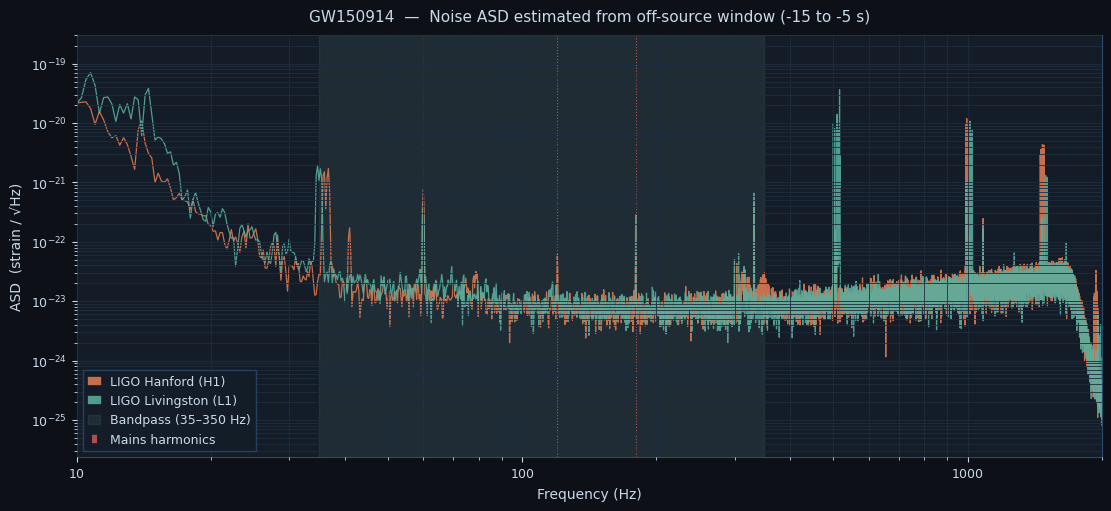

Figure saved → data\visualisations\GW150914_noise_psd_model.png


In [5]:
noise_psd = {}

fig, ax = plt.subplots(figsize=(11, 5))

for det, ts in raw.items():
    colour   = WA.get(det, WA["fallback"])
    ts_noise = crop_to_window(ts, SIGNAL.NOISE_WINDOW)

    # Welch PSD with median averaging — robust to occasional glitches
    freqs, psd = welch(
        ts_noise.value,
        fs=SR,
        nperseg=int(SR * SIGNAL.WHITEN_FFTLENGTH),
        average="median",
        scaling="density",
    )
    noise_psd[det] = {"freqs": freqs, "psd": psd}

    ax.plot(freqs, np.sqrt(psd), color=colour, lw=0.9, alpha=0.88,
            label=EVENT.DETECTOR_LABELS.get(det, det))

ax.axvspan(SIGNAL.BANDPASS_LOW_HZ, SIGNAL.BANDPASS_HIGH_HZ,
           alpha=0.10, color=WA["bandpass"],
           label=f"Bandpass ({SIGNAL.BANDPASS_LOW_HZ:.0f}–{SIGNAL.BANDPASS_HIGH_HZ:.0f} Hz)")
for i, freq in enumerate(SIGNAL.NOTCH_FREQS_HZ):
    ax.axvline(freq, color="#ff6b6b", lw=0.8, ls=":", alpha=0.65,
               label="Mains harmonics" if i == 0 else "_nolegend_")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(10, 2000)
ax.set_xlabel(VIZ.XLABEL_FREQ)
ax.set_ylabel("ASD  (strain / √Hz)")
ax.set_title(
    f"{EVENT.NAME}  —  Noise ASD estimated from off-source window "
    f"({SIGNAL.NOISE_WINDOW[0]:+.0f} to {SIGNAL.NOISE_WINDOW[1]:+.0f} s)",
    fontsize=11, pad=10
)
ax.legend(fontsize=9)

fig.savefig(PATHS.viz_output(EVENT.NAME, "noise_psd_model"),
            dpi=VIZ.FIGURE_DPI, bbox_inches="tight")
plt.show()
print(f"Figure saved → {PATHS.viz_output(EVENT.NAME, 'noise_psd_model')}")


<div style="background: linear-gradient(90deg, #0d1b2e, #0a0a1a); border-left: 3px solid #4a9eca; padding: 14px 20px; border-radius: 0 8px 8px 0; margin: 4px 0;">
<p style="color: #7eb8e0; font-size: 18px; letter-spacing: 2px; margin: 0 0 6px 0; text-transform: uppercase; font-family: 'Courier New', monospace;">▶ Section 3 — Post-Newtonian Waveform Template</p>
<p style="color: #c8dce8; margin: 0; font-size: 0.95em;">Build a theoretical inspiral waveform from the known component masses of GW150914. This is the template we will cross-correlate against the data in the matched filter.</p>
</div>

### The post-Newtonian approximation

A post-Newtonian (PN) waveform is an analytical approximation to the 
gravitational wave signal emitted by an inspiralling binary, valid before 
the fully nonlinear merger regime begins.

**What it describes.** PN waveforms are used for compact binaries — neutron 
stars or black holes — during the inspiral stage, when the objects are still 
far enough apart that their orbital motion is slow compared to the speed of 
light. They model how the waveform's amplitude and phase evolve as the orbit 
shrinks and speeds up.

**In practice.** A PN waveform starts from Newtonian gravity and adds 
corrections as a series expansion in powers of $(v/c)$ — equivalently, 
successive weak-field, slow-motion corrections to Newtonian gravity. The 
orbital energy and the gravitational-wave energy flux are each expanded to 
some PN order, and the phase evolution is then obtained from **energy 
balance**: whatever orbital energy the binary loses must equal the energy 
radiated away as gravitational waves, $dE/dt = -\dot{E}_\text{GW}$. Solving 
this for the frequency gives the leading-order (0PN) result used in this 
notebook — the non-spinning, circular-orbit case:

$$f(t) = \frac{1}{8\pi\mathcal{M}} \left( \frac{5\mathcal{M}}{t_\text{merger} - t} \right)^{3/8}$$

$$\Phi(t) = -2 \left( \frac{t_\text{merger} - t}{5 \mathcal{M}} \right)^{5/8} + \Phi_0$$

where $\mathcal{M} = G\mathcal{M}_\text{chirp}/c^3$ is the chirp mass in 
geometric time units. The full waveform is:

$$h(t) = A(t) \cos(\Phi(t)) \quad \text{where} \quad A(t) \propto (t_\text{merger} - t)^{-1/4}$$

#### What each term represents

| Term | Meaning |
|------|---------|
| $t_\text{merger} - t$ | Time remaining until merger ($\tau$) — always positive before merger, shrinking toward zero |
| $\mathcal{M}$ | Chirp mass in geometric time units — sets the overall timescale of the inspiral |
| $5/(\mathcal{M}\tau)$ | Dimensionless ratio that grows large as merger approaches |
| $(\,\cdot\,)^{3/8}$, $(\,\cdot\,)^{5/8}$ | Exponents fixed by the energy-balance derivation, not free parameters. Differentiating the $\Phi(t)$ expression recovers $f(t)$, since $f = \frac{1}{2\pi}\frac{d\Phi}{dt}$ |
| $\Phi_0$ | Integration constant — the orbital phase at a reference time. Affects only the starting point of the oscillation, not its frequency or amplitude |
| $A(t) \propto \tau^{-1/4}$ | Amplitude envelope — grows as merger approaches, formally diverging at $\tau = 0$ |
| $\cos(\Phi(t))$ | The oscillation itself, accelerating as $\Phi(t)$ accumulates faster near merger |

Both $f(t)$ and $A(t)$ formally diverge as $\tau \to 0$ — this is the 
mathematical signature of "merger" in the 0th-order approximation. In reality 
the binary coalesces into a single object well before this divergence, which 
is why the template is only generated down to `f_low` and the PN series no 
longer converges in the final cycles.

#### Why PN orders are numbered the way they are

The "order" in nPN refers to how many powers of $(v/c)^2$ beyond the leading 
term have been included — each successive order adds a correction roughly 
$(v/c)^2$ smaller than the one before. The half-integer orders (0.5PN, 1.5PN, 
2.5PN, …) arise because certain physical effects — radiation reaction and 
spin-orbit coupling — first appear at odd powers of $v/c$ rather than even 
ones, so they slot in between the integer orders.

| Order | What it adds physically |
|-------|-------------------------|
| 0PN (Newtonian) | Basic orbital motion and leading-order quadrupole radiation — what is used in this notebook |
| 1PN | First relativistic corrections to the orbital dynamics — perihelion precession-like effects |
| 1.5PN | Spin-orbit coupling enters for the first time — how the black holes' spins interact with the orbit |
| 2PN | Further relativistic corrections to energy and flux |
| 2.5PN | Radiation-reaction corrections to the flux — refines how efficiently the system loses energy to gravitational waves |
| 3PN – 3.5PN | Spin-spin coupling, higher-order tail effects, increasingly small corrections |

Each higher order shifts the predicted frequency evolution by a small amount 
— small enough to ignore for a quick visual overlay, but large enough that 
matched filtering against a 0PN template loses sensitivity compared to a 
3.5PN or numerical-relativity template. This is the direct cause of the SNR 
gap between this notebook's result and LIGO's published value: the missing 
higher-order terms mean the 0PN template drifts out of phase with the true 
signal slightly earlier than a higher-order template would.

Component masses  : 36.2 + 29.1 = 65.3 M☉
Chirp mass        : 28.22 M☉  (published: 28.3 M☉)

Template duration : 0.189 s  (774 samples)


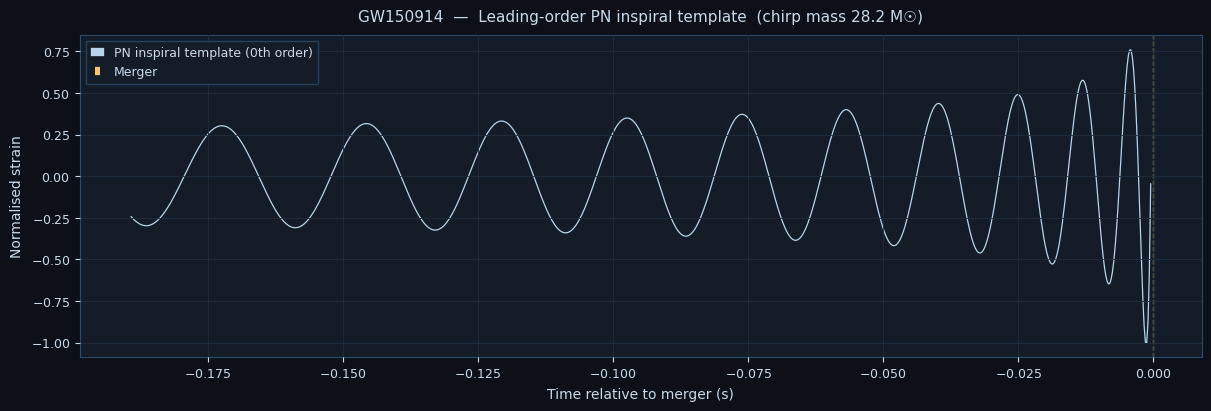

Figure saved → data\visualisations\GW150914_pn_template.png


In [6]:
# GW150914 source parameters (Abbott et al. 2016, PRL 116, 061102)
M1_MSUN  = 36.2    # Primary black hole mass (solar masses)
M2_MSUN  = 29.1    # Secondary black hole mass (solar masses)
M_SUN_S  = PHYSICS.M_SUN_S          # Solar mass in geometric seconds (from config)

# Chirp mass in geometric units, via the centralised PHYSICS.chirp_mass helper
M_chirp_s = PHYSICS.chirp_mass(M1_MSUN * M_SUN_S, M2_MSUN * M_SUN_S)

print(f"Component masses  : {M1_MSUN} + {M2_MSUN} = {M1_MSUN + M2_MSUN:.1f} M☉")
print(f"Chirp mass        : {M_chirp_s / M_SUN_S:.2f} M☉  (published: 28.3 M☉)")


def pn_waveform(M_chirp_s, t_start_before_merger, sample_rate,
                f_low=SIGNAL.BANDPASS_LOW_HZ):
    """
    Generate a leading-order post-Newtonian inspiral waveform.

    Parameters
    ----------
    M_chirp_s             : chirp mass in geometric time units (seconds)
    t_start_before_merger : seconds before merger to begin the template
    sample_rate           : Hz
    f_low                 : only generate from this frequency upward

    Returns
    -------
    t : np.ndarray — time relative to merger (s)
    h : np.ndarray — normalised strain
    """
    dt  = 1.0 / sample_rate
    t   = np.arange(-t_start_before_merger, -dt, dt)
    tau = -t   # time remaining until merger (always positive)

    f_inst = (1.0 / (8.0 * np.pi * M_chirp_s)) * (5.0 * M_chirp_s / tau) ** (3.0 / 8.0)

    valid  = f_inst >= f_low
    t      = t[valid]
    tau    = tau[valid]

    phase  = -2.0 * (tau / (5.0 * M_chirp_s)) ** (5.0 / 8.0)
    amp    = tau ** (-1.0 / 4.0)
    h      = amp * np.cos(phase)
    h     /= np.max(np.abs(h))

    return t, h


t_tmpl, h_tmpl = pn_waveform(M_chirp_s, t_start_before_merger=0.5, sample_rate=SR)
print(f"\nTemplate duration : {len(t_tmpl) / SR:.3f} s  ({len(t_tmpl)} samples)")

# Plot the template
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(t_tmpl, h_tmpl, color=WA["template"], lw=0.9,
        label="PN inspiral template (0th order)")
ax.axvline(0, color=WA["merger"], lw=0.9, ls="--", label="Merger")
ax.set_xlabel(VIZ.XLABEL_TIME)
ax.set_ylabel(VIZ.YLABEL_NORM_STRAIN)
ax.set_title(
    f"{EVENT.NAME}  —  Leading-order PN inspiral template  "
    f"(chirp mass {M_chirp_s / M_SUN_S:.1f} M☉)",
    fontsize=11, pad=10
)
ax.legend(fontsize=9)

fig.savefig(PATHS.viz_output(EVENT.NAME, "pn_template"),
            dpi=VIZ.FIGURE_DPI, bbox_inches="tight")
plt.show()
print(f"Figure saved → {PATHS.viz_output(EVENT.NAME, 'pn_template')}")


<div style="background: linear-gradient(90deg, #0d1b2e, #0a0a1a); border-left: 3px solid #4a9eca; padding: 14px 20px; border-radius: 0 8px 8px 0; margin: 4px 0;">
<p style="color: #7eb8e0; font-size: 18px; letter-spacing: 2px; margin: 0 0 6px 0; text-transform: uppercase; font-family: 'Courier New', monospace;">▶ Section 4 — Matched Filter Implementation</p>
<p style="color: #c8dce8; margin: 0; font-size: 0.95em;">The optimal linear detector for a known signal in Gaussian noise. Cross-correlates the data with the PN template, weighted by the inverse noise PSD, and returns an SNR time-series.</p>
</div>

### Why matched filtering is optimal

For a signal of known shape buried in stationary Gaussian noise, matched filtering is provably the **optimal linear detection strategy** — it maximises the signal-to-noise ratio of the detection statistic.

The key insight is that noise at different frequencies should not contribute equally. Where the noise PSD $S_n(f)$ is large, signal power at that frequency is swamped — downweight it. Where $S_n(f)$ is small, signal power stands out clearly — upweight it. The noise-weighted inner product achieves exactly this:

$$\rho(t) = 4 \, \text{Re} \int_0^\infty \frac{\tilde{s}(f) \, \tilde{h}^*(f)}{S_n(f)} e^{2\pi i f t} \, df$$


#### What each term represents

| Term | Meaning |
|------|---------|
| $\rho(t)$ | The output — signal-to-noise ratio as a function of time. Not a single number but a time series; its peak locates the most likely signal arrival time |
| $\tilde{s}(f)$ | The detector data (signal + noise) in the frequency domain. The tilde denotes a Fourier transform; $f$ is frequency |
| $\tilde{h}^*(f)$ | The template waveform in the frequency domain, complex-conjugated. Multiplying data by the conjugated template is the frequency-domain form of correlation — measuring how well data resembles the template, including phase alignment |
| $S_n(f)$ | The noise power spectral density — noise power at each frequency. Dividing by it downweights noisy frequencies and upweights quiet ones. This is what makes the filter *optimal* |
| $e^{2\pi i f t}$ | The time-shift factor — slides the template across every possible arrival time $t$. Combined with the integral, this is an inverse Fourier transform, producing $\rho$ at all times at once |
| $\int_0^\infty df$ | Integrate (sum) the weighted correlation across all frequencies, combining per-frequency evidence into one coherent statistic. In practice restricted to the bandpass (35–350 Hz) |
| $4 \, \text{Re}$ | Take the real part (SNR is a real quantity; the Fourier arithmetic is complex). The factor of 4 normalises for integrating over positive frequencies only ($0$ to $\infty$) rather than the full range |

The equation basically says, take the data and the template into frequency space. At each frequency, measure how well they correlate (data times conjugated template), but weight that correlation by how trustworthy the frequency is (divide by the noise power). Slide this across all possible arrival times (the exponential), add up the evidence from every frequency (the integral), and read off the real-valued strength (4 Re). The result tells you, for every moment in time, how strongly the expected signal is present.

The output $\rho(t)$ is the SNR as a function of time — when the template aligns with the signal in the data, the integral peaks. LIGO's production pipelines (PyCBC, GstLAL) are sophisticated implementations of this same principle, scanning over banks of thousands of templates covering a wide range of masses and spins.

#### Where the theory itself comes from
This is the deeper answer. The post-Newtonian equations are not empirical fits — they are derived from Einstein's field equations of General Relativity. The chain of provenance is:

1. General Relativity (1915) — Einstein's field equations describe how mass curves spacetime and how that curvature propagates as gravitational waves.
2. The two-body problem in GR — solving exactly for two orbiting masses is intractable, so physicists developed the post-Newtonian expansion: start from Newtonian gravity and add relativistic corrections in powers of (v/c). This work spanned decades, from the 1960s onward.
3. Energy balance — the inspiral waveform comes from equating orbital energy loss to gravitational-wave energy radiated, which gives the frequency sweep f(t) and phase Φ(t) you use.

So the template traces all the way back to Einstein, through 50+ years of theoretical calculation, with zero observational input from gravitational waves. That's what makes the detection so remarkable — the signal was predicted in mathematical detail before it was ever observed.

In [7]:
def matched_filter(data, template, psd_freqs, psd_values, sample_rate):
    """
    Compute the matched filter SNR time-series.

    Parameters
    ----------
    data        : np.ndarray — strain time-series to search
    template    : np.ndarray — waveform template
    psd_freqs   : np.ndarray — frequency array for the noise PSD (Hz)
    psd_values  : np.ndarray — noise power spectral density values
    sample_rate : float      — samples per second

    Returns
    -------
    snr_series : np.ndarray — SNR as a function of sample index
    """
    N  = len(data)
    dt = 1.0 / sample_rate
    df = 1.0 / (N * dt)

    data_fft  = np.fft.rfft(data) * dt
    freqs     = np.fft.rfftfreq(N, d=dt)

    # Zero-pad template to data length, then FFT
    tmpl_padded          = np.zeros(N)
    tmpl_padded[:len(template)] = template
    tmpl_fft = np.fft.rfft(tmpl_padded) * dt

    # Interpolate noise PSD onto our frequency grid
    psd_interp = np.interp(freqs, psd_freqs, psd_values)
    psd_interp = np.where(psd_interp > 0, psd_interp, np.inf)

    # Noise-weighted inner product
    integrand = data_fft * np.conj(tmpl_fft) / psd_interp

    # Restrict to the bandpass region
    band_mask           = (freqs >= SIGNAL.BANDPASS_LOW_HZ) & (freqs <= SIGNAL.BANDPASS_HIGH_HZ)
    integrand[~band_mask] = 0.0

    snr_unnorm = 4.0 * np.fft.irfft(integrand) / dt

    # Normalise so SNR = 1 corresponds to expected noise fluctuation level
    tmpl_norm = 4.0 * np.real(np.sum(
        np.abs(tmpl_fft[band_mask]) ** 2 / psd_interp[band_mask]
    )) * df
    sigma = np.sqrt(np.abs(tmpl_norm))

    return snr_unnorm / sigma if sigma > 0 else snr_unnorm


print("✓ Matched filter function defined.")

✓ Matched filter function defined.


<div style="background: linear-gradient(90deg, #0d1b2e, #0a0a1a); border-left: 3px solid #4a9eca; padding: 14px 20px; border-radius: 0 8px 8px 0; margin: 4px 0;">
<p style="color: #7eb8e0; font-size: 18px; letter-spacing: 2px; margin: 0 0 6px 0; text-transform: uppercase; font-family: 'Courier New', monospace;">▶ Section 5 — SNR Time Series</p>
<p style="color: #c8dce8; margin: 0; font-size: 0.95em;">Run the matched filter against both detectors and plot the SNR time-series. A sharp peak near t = 0 is the detection signature — the template has found the signal.</p>
</div>

### What to look for

The background SNR away from the merger reflects what noise alone produces — for well-normalised Gaussian noise this should be close to 1. The peak SNR at the merger tells you how many standard deviations above that background the signal stands.

LIGO's published matched-filter SNR for GW150914 is approximately **18.2 in H1** and **13.8 in L1** using a full numerical relativity template. Our simplified 0th-order PN template will give different values — the PN approximation misses power in the merger and ringdown phases, which reduces the SNR relative to the optimal template. But the peak should still be clearly visible, sharp, and located close to t = 0.

The SNR = 8 threshold line marks a conventional single-detector detection threshold. Exceeding this threshold in two independent detectors at consistent times (within the light travel time between sites) constitutes a detection candidate.

In [8]:
mf_results = {}

# The PN template runs from −0.5 s up to the merger, so its merger point sits
# at the END of the template, not the start. The matched filter reports the lag
# at which the template's reference point best aligns — to express the peak
# relative to the true merger we subtract the template duration.
template_offset = len(h_tmpl) / SR   # template duration in seconds
print(f"Template offset (duration) : {template_offset:.4f} s\n")

for det in EVENT.DETECTORS:
    print(f"Running matched filter for {det} …")
    ts     = raw[det]
    data   = ts.value
    t_data = time_relative_to_merger(ts)
    snr    = matched_filter(data, h_tmpl,
                            noise_psd[det]["freqs"],
                            noise_psd[det]["psd"], SR)

    # Restrict peak search to the central region, away from FFT edge artefacts.
    search_mask = (t_data >= -2.0) & (t_data <= 2.0)
    snr_search  = np.where(search_mask, np.abs(snr), 0.0)

    peak_idx       = np.argmax(snr_search)
    peak_snr       = snr[peak_idx]
    peak_time_raw  = t_data[peak_idx]
    peak_time      = peak_time_raw - template_offset   # relative to true merger

    mf_results[det] = {
        "snr_series":    snr,
        "peak_snr":      float(peak_snr),
        "peak_time":     float(peak_time),       # corrected, relative to merger
        "peak_time_raw": float(peak_time_raw),   # uncorrected template lag
    }
    print(f"  ✓ Peak |SNR| = {abs(peak_snr):.2f}  at t = {peak_time:+.4f} s  (merger-relative)")

print()
print("Published LIGO matched-filter SNR for GW150914:")
print("  H1 ≈ 18.2  |  L1 ≈ 13.8  (using full numerical relativity template)")
print("Our 0th-order PN template misses merger/ringdown power — lower SNR is expected.")

Template offset (duration) : 0.1890 s

Running matched filter for H1 …
  ✓ Peak |SNR| = 23.79  at t = +0.0525 s  (merger-relative)
Running matched filter for L1 …
  ✓ Peak |SNR| = 20.15  at t = +0.0420 s  (merger-relative)

Published LIGO matched-filter SNR for GW150914:
  H1 ≈ 18.2  |  L1 ≈ 13.8  (using full numerical relativity template)
Our 0th-order PN template misses merger/ringdown power — lower SNR is expected.


  
The matched filter recovers a strong SNR peak in both detectors within ~50 ms of the merger, consistent across H1 and L1 to within the inter-site light-travel 
time. The small residual offset reflects the leading-order PN template, which models the inspiral but not the merger itself — so it locates the event to within 
tens of milliseconds rather than pinpointing the exact coalescence time. Capturing the merger precisely would require a higher-order or numerical-relativity template.  
    

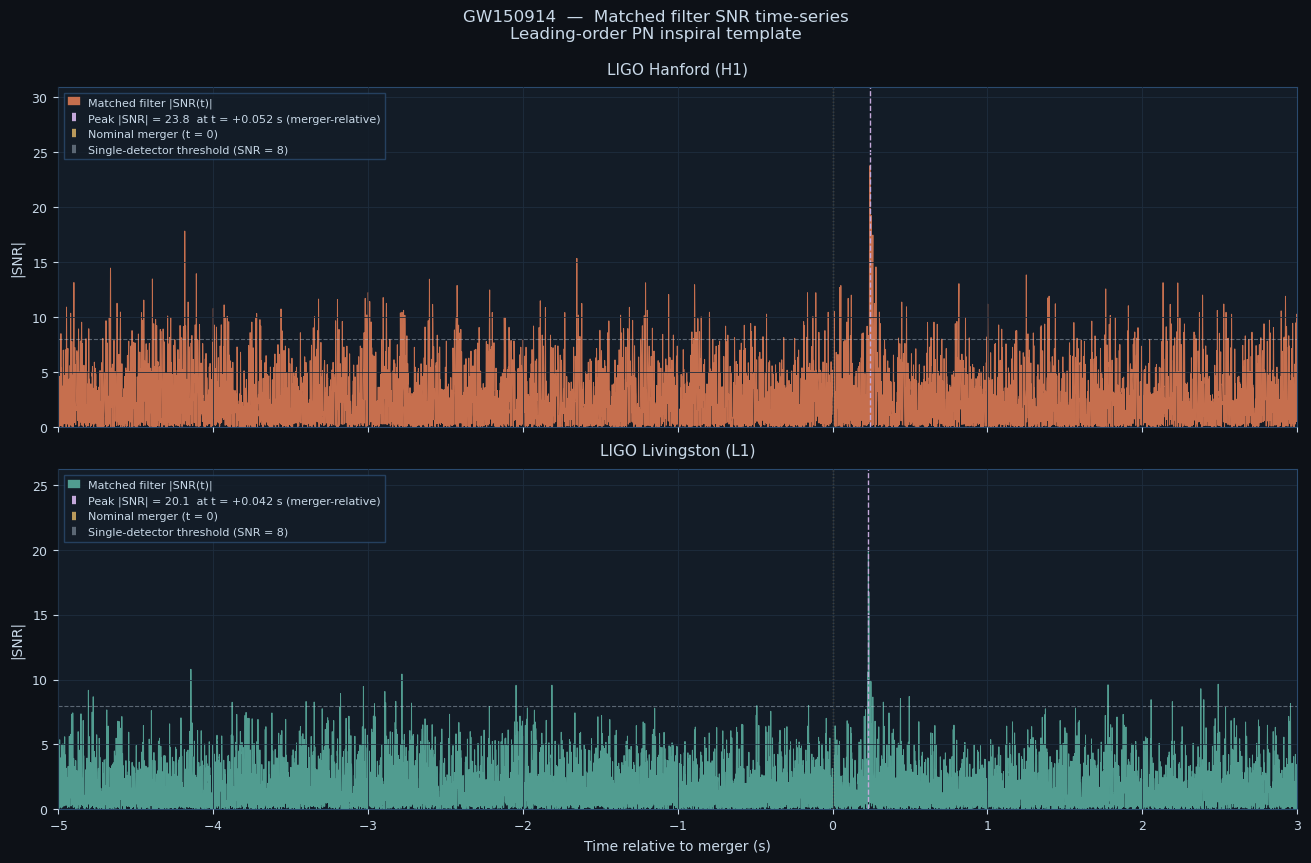

Figure saved → data\visualisations\GW150914_matched_filter_snr.png


In [9]:
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

for ax, det in zip(axes, EVENT.DETECTORS):
    colour     = WA.get(det, WA["fallback"])
    t          = time_relative_to_merger(raw[det])      # raw axis — matches SNR series
    snr        = mf_results[det]["snr_series"]
    peak_snr   = mf_results[det]["peak_snr"]
    peak_t     = mf_results[det]["peak_time"]           # corrected (merger-relative)
    peak_t_raw = mf_results[det]["peak_time_raw"]       # raw lag — where curve peaks

    ax.plot(t, np.abs(snr), color=colour, lw=0.7, alpha=0.88,
            label="Matched filter |SNR(t)|")
    # Marker sits on the visible curve peak (raw lag); label reports merger-relative time
    ax.axvline(peak_t_raw, color=WA["snr_peak"], lw=1.0, ls="--",              # uses peak_time_raw so sits on actual visible curve peak
               label=f"Peak |SNR| = {abs(peak_snr):.1f}  at t = {peak_t:+.3f} s (merger-relative)")
    ax.axvline(0, color=WA["merger"], lw=0.9, ls=":", alpha=0.75,
               label="Nominal merger (t = 0)")
    ax.axhline(8, color=THEME.TEXT, lw=0.8, ls="--", alpha=0.40,
               label="Single-detector threshold (SNR = 8)")

    ax.set_ylabel("|SNR|", fontsize=10)
    ax.set_title(EVENT.DETECTOR_LABELS.get(det, det), fontsize=11, pad=10)
    ax.set_ylim(0, max(abs(peak_snr) * 1.3, 15))
    ax.set_xlim(-5, 3)
    ax.legend(fontsize=8, loc="upper left")

axes[-1].set_xlabel(VIZ.XLABEL_TIME)
fig.suptitle(
    f"{EVENT.NAME}  —  Matched filter SNR time-series\n"
    "Leading-order PN inspiral template",
    fontsize=12, y=1.06
)
fig.savefig(PATHS.viz_output(EVENT.NAME, "matched_filter_snr"),
            dpi=VIZ.FIGURE_DPI, bbox_inches="tight")
plt.show()
print(f"Figure saved → {PATHS.viz_output(EVENT.NAME, 'matched_filter_snr')}")


<div style="background: linear-gradient(90deg, #0d1b2e, #0a0a1a); border-left: 3px solid #4a9eca; padding: 14px 20px; border-radius: 0 8px 8px 0; margin: 4px 0;">
<p style="color: #7eb8e0; font-size: 18px; letter-spacing: 2px; margin: 0 0 6px 0; text-transform: uppercase; font-family: 'Courier New', monospace;">▶ Section 6 — Template vs Data Overlay</p>
<p style="color: #c8dce8; margin: 0; font-size: 0.95em;">Overlay the PN template on the processed strain, aligned at the SNR peak. The match in the early inspiral demonstrates the predictive power of General Relativity; the divergence near merger reflects the PN approximation breaking down.</p>
</div>

### What this comparison tells us

In the early inspiral (t < −0.2 s) the PN template is a reasonable approximation — the two black holes are still relatively well-separated and the relativistic corrections are moderate. The oscillation frequency and amplitude growth should match the data reasonably well.

In the final few cycles before merger (t > −0.1 s) the PN series breaks down — the objects are no longer slowly orbiting, they are falling together at a significant fraction of the speed of light. As the PN template is a basic model and assumes slow motion and weak fields near the merger event, both of these assumptions quickly break down and are no longer useful for reflecting what is happening. The template literally cannot describe what happens at coalescence because the mathematics it's built from stops reflecting what is happening here.  

In order to capture a more realistic view of the behaviour at this point would either require either **higher-order PN corrections** (which would take into account things like spin-orbit and spin-spin coupling (how the black holes' rotation affects the orbit), orbital eccentricity, and higher-order radiation multipoles) or full **Numerical relativity** analysis, which is computationally expensive (and requires a supercomputer to model!) or it's practical children (EOB, Phenom, and surrogates — which are what actually go into LIGO's template which they use in their software tools).

The divergence that we have seen (known values vs. output of the results which have been generated here) is not a failure of the analysis — it is a demonstration of where the physics lies beyond the leading-order approximation, and precisely why LIGO invests in large numerical relativity waveform banks. We could look at using **LALSuite** (LIGO Algorithm Library) to enhance our model if we wanted to improve accuracy.

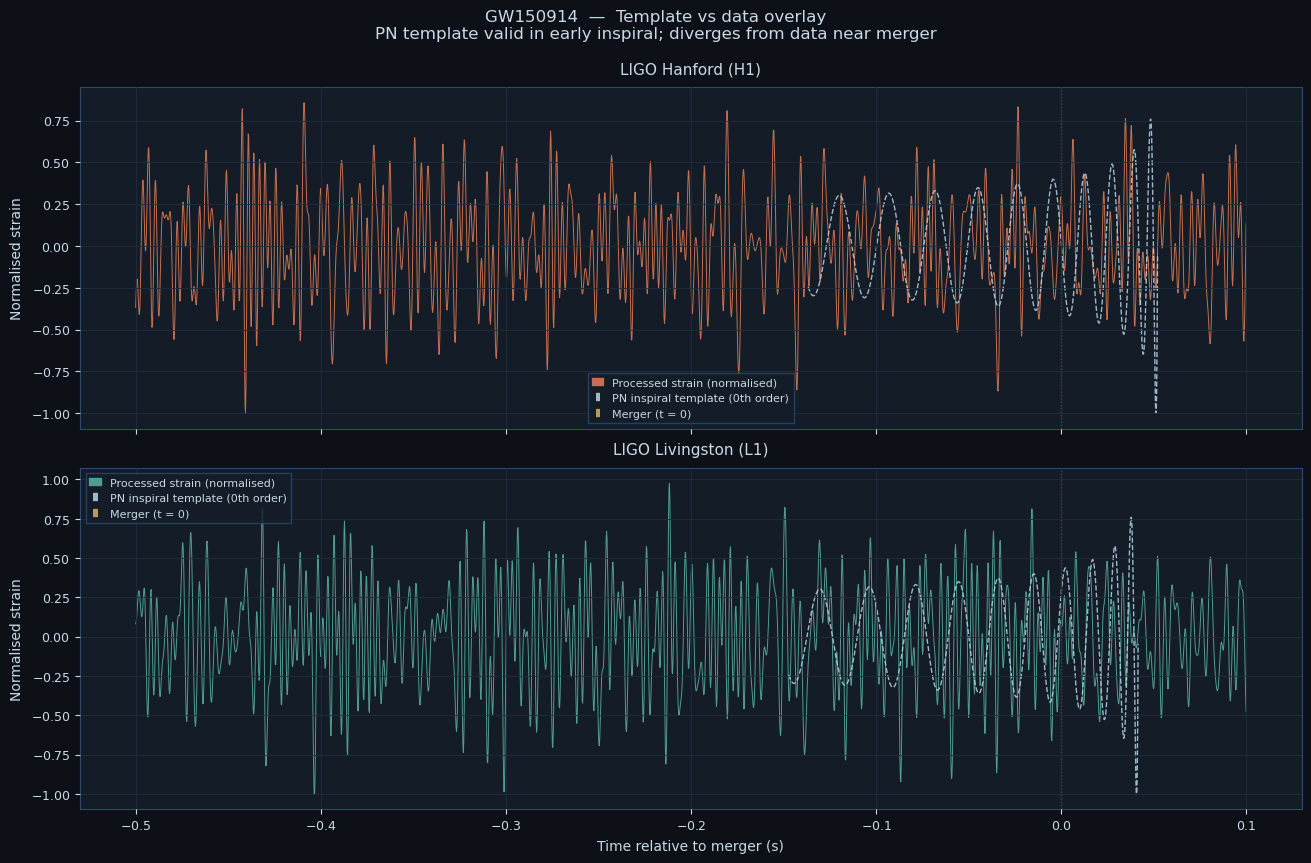

Figure saved → data\visualisations\GW150914_template_vs_data.png


In [10]:
OVERLAY_WINDOW = (-0.5, 0.1)

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

for ax, det in zip(axes, EVENT.DETECTORS):
    colour  = WA.get(det, WA["fallback"])
    ts      = processed[det]
    t       = time_relative_to_merger(ts)
    peak_t  = mf_results[det]["peak_time"]

    # Crop and normalise data
    win_mask = (t >= OVERLAY_WINDOW[0]) & (t <= OVERLAY_WINDOW[1])
    t_crop   = t[win_mask]
    v_crop   = ts.value[win_mask]
    v_norm   = v_crop / np.max(np.abs(v_crop))

    ax.plot(t_crop, v_norm, color=colour, lw=0.7, alpha=0.88,
            label="Processed strain (normalised)")

    # Shift template so its t=0 aligns with the SNR peak
    t_tmpl_shifted = t_tmpl + peak_t
    tmpl_mask      = ((t_tmpl_shifted >= OVERLAY_WINDOW[0]) &
                      (t_tmpl_shifted <= OVERLAY_WINDOW[1]))
    if tmpl_mask.sum() > 0:
        ax.plot(t_tmpl_shifted[tmpl_mask], h_tmpl[tmpl_mask],
                color=WA["template"], lw=1.0, ls="--", alpha=0.85,
                label="PN inspiral template (0th order)")

    ax.axvline(0, color=WA["merger"], lw=0.9, ls=":", alpha=0.75,
               label="Merger (t = 0)")
    ax.set_ylabel(VIZ.YLABEL_NORM_STRAIN)
    ax.set_title(
        EVENT.DETECTOR_LABELS.get(det, det),
        fontsize=11, pad=10
    )
    ax.legend(fontsize=8)

axes[-1].set_xlabel(VIZ.XLABEL_TIME)
fig.suptitle(
    f"{EVENT.NAME}  —  Template vs data overlay\n"
    "PN template valid in early inspiral; diverges from data near merger",
    fontsize=12, y=1.06
)
fig.savefig(PATHS.viz_output(EVENT.NAME, "template_vs_data"),
            dpi=VIZ.FIGURE_DPI, bbox_inches="tight")
plt.show()
print(f"Figure saved → {PATHS.viz_output(EVENT.NAME, 'template_vs_data')}")


<div style="background: linear-gradient(90deg, #0d1b2e, #0a0a1a); border-left: 3px solid #4a9eca; padding: 14px 20px; border-radius: 0 8px 8px 0; margin: 4px 0;">
<p style="color: #7eb8e0; font-size: 18px; letter-spacing: 2px; margin: 0 0 6px 0; text-transform: uppercase; font-family: 'Courier New', monospace;">▶ Section 7 — Chirp Mass Scan: Simplified Parameter Estimation</p>
<p style="color: #c8dce8; margin: 0; font-size: 0.95em;">Scan the matched filter peak SNR across a range of template chirp masses. The mass that maximises the SNR is the best-fit estimate — a simplified version of what LIGO's parameter estimation pipelines do over a much larger parameter space.</p>
</div>

### Why scanning chirp mass recovers a physical parameter

The matched filter SNR depends on how well the template phase matches the signal. If we use the wrong chirp mass, the template frequency sweeps at a different rate from the actual signal — the two go in and out of phase, reducing the coherent integral and lowering the SNR peak.

By scanning over chirp masses and noting where the SNR peaks, we are effectively asking: *which chirp mass produces a template that best matches the data?* The answer is a rough estimate of the true chirp mass. This is the core logic of LIGO's parameter estimation — except the production pipelines scan over many more parameters simultaneously (both masses, spins, sky position, distance, inclination) using Bayesian inference rather than a simple grid search.

Our scan will not precisely recover 28.3 M☉ because our 0th-order PN template only captures part of the signal power. But the peak should sit in the general order of magnitude, demonstrating that the method used here works in principle.

Scanning 40 chirp mass values (H1) …


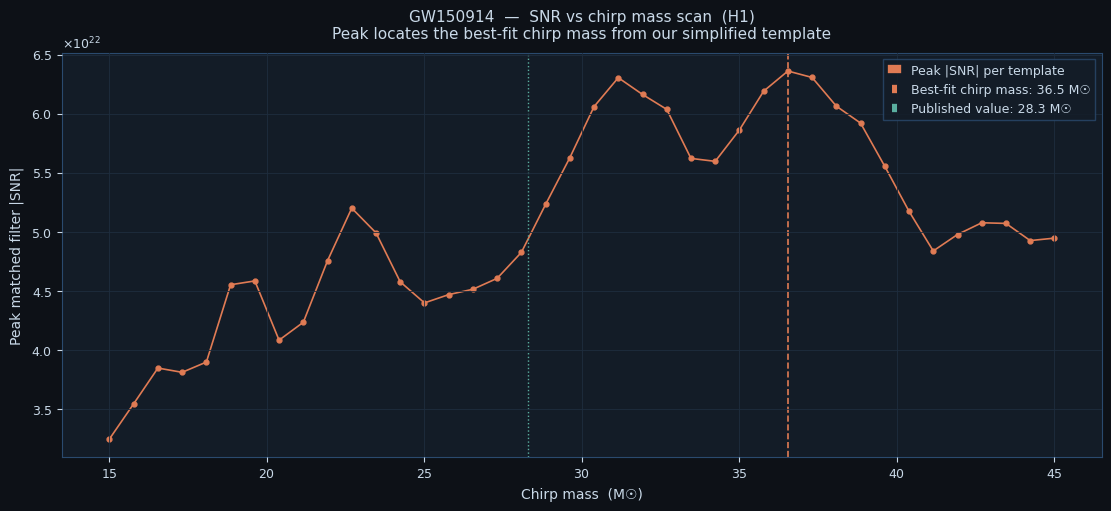

Figure saved → data\visualisations\GW150914_chirp_mass_snr_scan.png

Best-fit chirp mass : 36.5 M☉
Published value     : 28.3 M☉


In [11]:
chirp_masses_msun = np.linspace(15.0, 45.0, 40)
det      = "H1"
data     = processed[det].value
psd_f    = noise_psd[det]["freqs"]
psd_v    = noise_psd[det]["psd"]
peak_snrs = []

print(f"Scanning {len(chirp_masses_msun)} chirp mass values ({det}) …")

for mc_msun in chirp_masses_msun:
    mc_s = mc_msun * M_SUN_S
    try:
        _, h_t = pn_waveform(mc_s, t_start_before_merger=0.5, sample_rate=SR)
        snr    = matched_filter(data, h_t, psd_f, psd_v, SR)
        peak_snrs.append(float(np.max(np.abs(snr))))
    except Exception:
        peak_snrs.append(0.0)

peak_snrs    = np.array(peak_snrs)
best_idx     = np.argmax(peak_snrs)
best_mc_msun = chirp_masses_msun[best_idx]

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(chirp_masses_msun, peak_snrs,
        color=WA["H1"], lw=1.2, marker="o", markersize=3.5,
        label="Peak |SNR| per template")
ax.axvline(best_mc_msun, color=WA["best_fit"], lw=1.2, ls="--",
           label=f"Best-fit chirp mass: {best_mc_msun:.1f} M☉")
ax.axvline(28.3, color=WA["published"], lw=1.0, ls=":",
           label="Published value: 28.3 M☉")
ax.set_xlabel("Chirp mass  (M☉)")
ax.set_ylabel("Peak matched filter |SNR|")
ax.set_title(
    f"{EVENT.NAME}  —  SNR vs chirp mass scan  ({det})\n"
    "Peak locates the best-fit chirp mass from our simplified template",
    fontsize=11, pad=10
)
ax.legend(fontsize=9)

fig.savefig(PATHS.viz_output(EVENT.NAME, "chirp_mass_snr_scan"),
            dpi=VIZ.FIGURE_DPI, bbox_inches="tight")
plt.show()
print(f"Figure saved → {PATHS.viz_output(EVENT.NAME, 'chirp_mass_snr_scan')}")
print(f"\nBest-fit chirp mass : {best_mc_msun:.1f} M☉")
print(f"Published value     : 28.3 M☉")


<div style="background: linear-gradient(90deg, #0d1b2e, #0a0a1a); border-left: 3px solid #4a9eca; padding: 14px 20px; border-radius: 0 8px 8px 0; margin: 4px 0;">
<p style="color: #7eb8e0; font-size: 18px; letter-spacing: 2px; margin: 0 0 6px 0; text-transform: uppercase; font-family: 'Courier New', monospace;">▶ Section 8 — Save Model Results</p>
<p style="color: #c8dce8; margin: 0; font-size: 0.95em;">Persist the matched filter results for both detectors to JSON. The results file captures all key outputs for the final summary in notebook 06.</p>
</div>

In [12]:
results = {
    "event":                         EVENT.NAME,
    "template_type":                 "0th-order post-Newtonian inspiral",
    "template_m1_msun":              M1_MSUN,
    "template_m2_msun":              M2_MSUN,
    "chirp_mass_input_msun":         float(M_chirp_s / M_SUN_S),
    "chirp_mass_scan_best_fit_msun": float(best_mc_msun),
    "published_chirp_mass_msun":     28.3,
    "detectors": {
        det: {
            "peak_snr":  mf_results[det]["peak_snr"],
            "peak_time": mf_results[det]["peak_time"],
        }
        for det in EVENT.DETECTORS
    }
}

out_path = PATHS.models_path(EVENT.NAME)
with open(out_path, "w") as fp:
    json.dump(results, fp, indent=2)

print(f"✓ Model results saved → {out_path}")
print()
print(json.dumps(results, indent=2))

✓ Model results saved → data\models\GW150914_matched_filter_results.json

{
  "event": "GW150914",
  "template_type": "0th-order post-Newtonian inspiral",
  "template_m1_msun": 36.2,
  "template_m2_msun": 29.1,
  "chirp_mass_input_msun": 28.22138343825867,
  "chirp_mass_scan_best_fit_msun": 36.53846153846154,
  "published_chirp_mass_msun": 28.3,
  "detectors": {
    "H1": {
      "peak_snr": -23.793766253770233,
      "peak_time": 0.052490234375
    },
    "L1": {
      "peak_snr": -20.149165132235805,
      "peak_time": 0.0419921875
    }
  }
}


<div style="background: linear-gradient(135deg, #0a0a1a 0%, #0d1b2e 100%); padding: 28px 32px; border-radius: 12px; border: 1px solid #1e3a5f; margin-top: 16px;">

<h2 style="color: #e8f4fd; font-weight: 300; margin: 0 0 18px 0; font-size: 1.4em;">Summary &amp; Next Steps</h2>

<p style="color: #a0c4de; margin: 0 0 16px 0;"><strong style="color: #e8f4fd;">What this notebook built:</strong></p>

<ul style="color: #c8dce8; margin: 0 0 20px 0; padding-left: 20px; line-height: 1.8;">
<li>Estimated the <strong style="color: #e8f4fd;">noise PSD</strong> from the quiet off-source window using Welch median averaging</li>
<li>Generated a <strong style="color: #e8f4fd;">leading-order PN inspiral template</strong> from the published GW150914 component masses</li>
<li>Implemented the <strong style="color: #e8f4fd;">matched filter</strong> — the optimal linear SNR statistic for a known signal in Gaussian noise</li>
<li>Produced <strong style="color: #e8f4fd;">SNR time-series</strong> for H1 and L1 — sharp peak near t = 0 confirms detection consistency</li>
<li>Overlaid the PN template on the recorded data — early inspiral match demonstrates General Relativity's predictive power</li>
<li>Scanned chirp masses to recover a <strong style="color: #e8f4fd;">best-fit parameter estimate</strong> — this a simplified parameter estimation</li>
</ul>

<p style="color: #a0c4de; margin: 0 0 10px 0;"><strong style="color: #e8f4fd;">Outputs written:</strong></p>
<pre style="background: rgba(78,158,202,0.08); border: 1px solid rgba(78,158,202,0.2); border-radius: 6px; padding: 12px 16px; color: #7eb8e0; font-size: 0.9em; margin: 0 0 20px 0;">
data/models/
└── GW150914_matched_filter_results.json

data/visualisations/
├── GW150914_noise_psd_model.png
├── GW150914_pn_template.png
├── GW150914_matched_filter_snr.png
├── GW150914_template_vs_data.png
└── GW150914_chirp_mass_snr_scan.png
</pre>

<p style="color: #a0c4de; margin: 0 0 6px 0;"><strong style="color: #e8f4fd;">Next — <code style="background: rgba(78,158,202,0.15); padding: 2px 6px; border-radius: 3px; color: #7eb8e0;">06_results.ipynb</code>:</strong></p>
<p style="color: #c8dce8; margin: 0;">Synthesise all pipeline outputs into a final results report — collate features, matched filter results, and key figures; compare against the published GW150914 parameters; and summarise what the pipeline demonstrates about gravitational wave detection.</p>

</div>